# Step 6 - Losses and derivative checks

Assemble the three inversion losses against the step-5 testset and verify their gradients w.r.t. the
field params make sense:
* **fit** - chi^2 of synthesized Stokes vs the observations on random pixels;
* **HE** - hydrostatic equilibrium `dP/dz = -rho g` (physical units, rho from the EOS) at random collocation points;
* **boundary** - soft top gas-pressure constraint.

Each is checked with a central finite-difference along a random direction (`directional_fd`), then we
confirm a few gradient-descent steps actually reduce the total loss (i.e. the gradients are usable).

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('.')); sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('../3dtesting')); sys.path.insert(0, os.path.abspath('../eos_mlp'))
import gpu; dev = gpu.use_gpu()
%matplotlib inline
import time, numpy as np, matplotlib.pyplot as plt, jax, jax.numpy as jnp, optax
import atmosphere_field as af, losses as L, eos as eos_mod
from synth3d import read_kurucz, DEFAULT_LINELIST
print('CUDA_VISIBLE_DEVICES =', dev, '| jax backend:', jax.default_backend())

CUDA_VISIBLE_DEVICES = 0 | jax backend: gpu


In [4]:
params = af.load_params('/dat/milic/adora_pinn_develop/pretrained_field.npz')
eos_params = eos_mod.load_eos('pg')
d = np.load('/dat/milic/adora_pinn_develop/inversion_testset.npz', allow_pickle=True)
obs = jnp.asarray(d['I_obs']); waves = jnp.asarray(d['waves'])
adata = read_kurucz(DEFAULT_LINELIST)
nz = 56; dz = jnp.full(nz, 20.0e3)
synth_fn = L.make_synth(eos_params)

P_TOP = 3.75          # Pa, top gas pressure of the FAL-C starting atmosphere # Good 

sigma = jnp.full(4, 1e-3*float(obs[...,0,0].mean()))   # per-Stokes noise ~1e-3 <Ic>
print('obs', obs.shape, ' sigma', float(sigma[0]))

obs (128, 128, 4, 201)  sigma 0.031026658730714675


### The three losses (fixed random samples)

In [5]:
k = jax.random.split(jax.random.PRNGKey(0), 6)
M = 256
ix = jax.random.randint(k[0], (M,), 0, 128); iy = jax.random.randint(k[1], (M,), 0, 128)
obs_b = obs[ix, iy]
colloc = jax.random.uniform(k[2], (1024, 3), minval=-1.0, maxval=1.0)
ixb = jax.random.randint(k[3], (256,), 0, 128); iyb = jax.random.randint(k[4], (256,), 0, 128)
fit = lambda p: L.fit_loss(p, synth_fn, adata, obs_b, ix, iy, nz, waves, dz, sigma)
he  = lambda p: L.he_loss(p, eos_params, colloc)
bnd = lambda p: L.boundary_loss(p, ixb, iyb, P_TOP)
W_FIT, W_HE, W_BND = 1.0, 1.0, 10.0        # example weights (boundary high); tune in the real inversion
total = lambda p: W_FIT*fit(p) + W_HE*he(p) + W_BND*bnd(p)
print(f'fit      = {float(fit(params)):.4e}')
print(f'he       = {float(he(params)):.4e}')
print(f'boundary = {float(bnd(params)):.4e}')
print(f'total    = {float(total(params)):.4e}')

fit      = 9.6063e+03
he       = 1.6976e-02
boundary = 2.9204e-05
total    = 9.6063e+03


### Derivative check: central FD vs analytic gradient along a random direction
`rel_err` small (and grads finite) means autodiff through the field, EOS and RT is correct.

In [6]:
v = L.random_like(params, jax.random.PRNGKey(7), 1.0)
print(f'{"loss":9s} {"value":>12s} {"FD":>13s} {"analytic":>13s} {"rel_err":>10s}  finite')
for name, f in [('fit', fit), ('he', he), ('boundary', bnd), ('total', total)]:
    fd, an, rel = L.directional_fd(f, params, v, eps=1e-4)
    g = jax.grad(f)(params)
    fin = all(bool(np.isfinite(np.asarray(l)).all()) for l in jax.tree_util.tree_leaves(g))
    print(f'{name:9s} {f(params):12.4e} {fd:+13.4e} {an:+13.4e} {rel:10.2e}  {fin}')

loss             value            FD      analytic    rel_err  finite
fit         9.6063e+03   +1.0707e+03   +1.0761e+03   5.03e-03  True
he          1.6976e-02   -3.5610e-01   -3.5679e-01   1.94e-03  True
boundary    2.9204e-05   -5.9947e-03   -5.9921e-03   4.24e-04  True
total       9.6063e+03   +1.0703e+03   +1.0757e+03   5.03e-03  True


### The gradients are usable: a few descent steps reduce the total loss
A short Adam run on the fixed samples (a sanity check, not the full inversion) - the total loss and
the fit chi^2 drop, and Stokes V (absent in the B=0 start) begins to appear.

In [21]:
def synth_batch(p, ix, iy):
    out = af.forward(p, L.pixel_column_coords(ix, iy, nz)); 
    r = lambda a: a.reshape(ix.shape[0], nz)
    b, gb, cb = af.b_to_rt_angles(out['Bx'], out['By'], out['Bz'])
    return synth_fn(adata, waves, dz, r(out['T']), r(out['P']), r(out['vz']), r(out['vturb']), r(b), r(gb), r(cb))

150 steps in 76s   total 9.606e+03 -> 1.557e+01


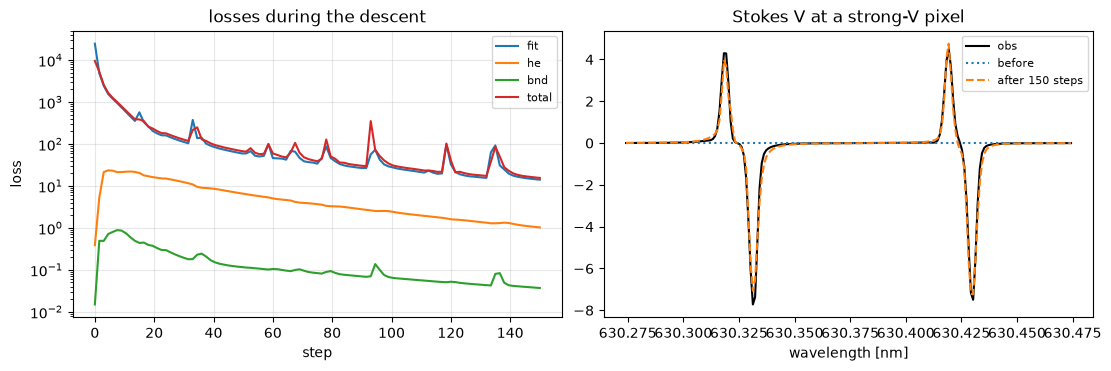

In [ ]:
jp = np.unravel_index(int(np.argmax(np.abs(np.asarray(obs_b[:,3,:])).max(-1))), (M,))[0]  # strong-V pixel in batch
V_before = np.asarray(synth_batch(params, ix, iy))[jp, 3]
opt = optax.adam(3e-3); state = opt.init(params); p = params
@jax.jit
def step(p, state):
    l, g = jax.value_and_grad(total)(p); u, state = opt.update(g, state, p); return optax.apply_updates(p, u), state, l
hist = {'fit':[], 'he':[], 'bnd':[], 'total':[]}
t0 = time.time()
N_steps_test = 1000
for it in range(N_steps_test):
    p, state, l = step(p, state)
    if it % 10 == 0 or it == N_steps_test-1:
        hist['fit'].append(float(fit(p))); hist['he'].append(float(he(p)))
        hist['bnd'].append(float(bnd(p))); hist['total'].append(float(l))
print(f'{N_steps_test} steps in {time.time()-t0:.0f}s   total {hist["total"][0]:.3e} -> {hist["total"][-1]:.3e}')
V_after = np.asarray(synth_batch(p, ix, iy))[jp, 3]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6), layout='constrained')
for kk in ['fit','he','bnd','total']: ax[0].semilogy(np.linspace(0,N_steps_test,len(hist[kk])), hist[kk], label=kk)
ax[0].set(xlabel='step', ylabel='loss', title='losses during the descent'); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
ax[1].plot(waves, np.asarray(obs_b[jp,]), 'k-', label='obs'); ax[1].plot(waves, V_before, 'C0:', label='before')
ax[1].plot(waves, V_after, 'C1--', label=f'after {N_steps_test} steps')
ax[1].set(xlabel='wavelength [nm]', title='Stokes V at a strong-V pixel'); ax[1].legend(fontsize=8)
plt.show()

### Summary
All three losses are implemented against the testset and are **differentiable w.r.t. the field**: FD and
analytic gradients agree (fit ~1e-4, boundary ~1e-3, HE ~1e-2 as expected for its nested grad), and no
NaNs (the key fix was making `b_to_rt_angles` gradient-safe at B=0, the inversion's starting point).
A short descent reduces the total loss and starts introducing Stokes V. The machinery for the full
inversion is in place.